# **Klasifikasi Kualitas Udara Dengan Menggunakan Metode Decision Tree dan Random Forest Di Kota Ballarat, Australia**

**1. Import Library yang Digunakan**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score)

*Bagian ini digunakan untuk memanggil seluruh pustaka (library) yang diperlukan dalam proses pengolahan data, pemodelan, serta evaluasi hasil klasifikasi.*
*1. pandas dan numpy digunakan untuk manipulasi dan pengolahan data numerik.*

*2. matplotlib dan seaborn digunakan untuk visualisasi data dan hasil evaluasi model.*

*3. train_test_split digunakan untuk membagi dataset menjadi data latih dan data uji.*

*4. LabelEncoder digunakan untuk mengubah data kategorikal menjadi numerik.*

*5. DecisionTreeClassifier dan RandomForestClassifier digunakan sebagai algoritma klasifikasi.*

*6. confusion_matrix, classification_report, dan accuracy_score digunakan untuk mengevaluasi performa model.*

**2. Membaca Dataset Kualitas Udara**

In [ ]:
df = pd.read_csv('air_quality_observation.csv')
df.head()

,device_id,date_time,location_description,latitude,longitude,pm1,pm25,pm10,ozone,nitrogen_dioxide,carbon_monoxide,air_quality_category,point
0,ems-b879,2023-01-16T18:41:12+00:00,Fairyland,-37.546758,143.823172,2,2,3,94,134,-3629,Poor,"-37.546758, 143.823172"
1,ems-b879,2023-01-17T00:26:09+00:00,Fairyland,-37.546758,143.823172,3,3,4,70,97,-1006,Fair,"-37.546758, 143.823172"
2,ems-b879,2023-01-17T02:41:07+00:00,Fairyland,-37.546758,143.823172,2,2,2,75,104,218,Fair,"-37.546758, 143.823172"
3,ems-b879,2023-01-17T03:26:07+00:00,Fairyland,-37.546758,143.823172,2,2,2,61,104,743,Fair,"-37.546758, 143.823172"
4,ems-b879,2023-01-15T05:11:27+00:00,Fairyland,-37.546758,143.823172,0,0,0,70,119,-2143,Fair,"-37.546758, 143.823172"


*Kode ini digunakan untuk membaca dataset kualitas udara yang tersimpan dalam format CSV. Dataset kemudian dimuat ke dalam sebuah DataFrame bernama df. Fungsi head() digunakan untuk menampilkan lima baris pertama data sebagai tahap awal eksplorasi dataset.*

**3. Melihat Struktur dan Statistik Data**

In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125492 entries, 0 to 125491
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   device_id             125492 non-null  object 
 1   date_time             125491 non-null  object 
 2   location_description  125492 non-null  object 
 3   latitude              125492 non-null  float64
 4   longitude             125492 non-null  float64
 5   pm1                   125492 non-null  int64  
 6   pm25                  125492 non-null  int64  
 7   pm10                  125492 non-null  int64  
 8   ozone                 125492 non-null  int64  
 9   nitrogen_dioxide      125492 non-null  int64  
 10  carbon_monoxide       125492 non-null  int64  
 11  air_quality_category  125492 non-null  object 
 12  point                 125492 non-null  object 
dtypes: float64(2), int64(6), object(5)
memory usage: 12.4+ MB
None
            latitude      longitude      

*Tahap ini bertujuan untuk memahami struktur dataset.*

*df.info() menampilkan jumlah baris, jumlah kolom, tipe data setiap kolom, serta keberadaan nilai kosong (missing value).*

*df.describe() menampilkan statistik deskriptif seperti nilai minimum, maksimum, rata-rata, dan standar deviasi untuk setiap kolom numerik.*

**4. Menangani Nilai Negatif pada Variabel Numerik**

In [ ]:
numeric_cols = ['pm1','pm25','pm10','ozone','nitrogen_dioxide','carbon_monoxide']
for col in numeric_cols:
    df[col] = df[col].apply(lambda x: np.nan if x < 0 else x)

df.isnull().sum()

,0
device_id,0
date_time,1
location_description,0
latitude,0
longitude,0
pm1,0
pm25,0
pm10,0
ozone,142
nitrogen_dioxide,100


*Pada tahap ini dilakukan pembersihan data dengan mengganti nilai negatif pada variabel polutan udara menjadi NaN. Nilai negatif dianggap tidak valid secara ilmiah karena konsentrasi polutan udara tidak mungkin bernilai negatif.*

**5. Mengisi Missing Value dengan Median**

In [ ]:
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

*Nilai yang sebelumnya diubah menjadi NaN kemudian diisi menggunakan nilai median dari masing-masing kolom. Median dipilih karena lebih tahan terhadap outlier dibandingkan nilai rata-rata.*

In [ ]:
df.isnull().sum()

,0
device_id,0
date_time,1
location_description,0
latitude,0
longitude,0
pm1,0
pm25,0
pm10,0
ozone,0
nitrogen_dioxide,0


**6. Menentukan Variabel Fitur dan Target**

In [ ]:
# Kolom fitur
X = df[['pm1','pm25','pm10','ozone','nitrogen_dioxide','carbon_monoxide']]

# Kolom target
y = df['air_quality_category']


*X berisi variabel input (fitur) berupa konsentrasi polutan udara.*

*y merupakan variabel target berupa kategori kualitas udara yang akan diklasifikasikan.*

**7. Encoding Variabel Target**

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Label encoded:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Label encoded: {'Fair': np.int64(0), 'Good': np.int64(1), 'Hazardous': np.int64(2), 'Moderate': np.int64(3), 'Poor': np.int64(4), 'Very Poor': np.int64(5)}


*Variabel target air_quality_category yang berbentuk teks dikonversi menjadi nilai numerik menggunakan LabelEncoder. Langkah ini diperlukan karena algoritma machine learning tidak dapat memproses data kategorikal secara langsung.*

**8. Pembagian Data Training dan Testing**

In [ ]:
# Create a mask to identify non-null target values in the original 'y'
non_null_mask = y.notna()

# Filter X and y_encoded based on the mask to remove the NaN sample
X_filtered = X[non_null_mask]
y_encoded_filtered = y_encoded[non_null_mask]

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_encoded_filtered, test_size=0.2, random_state=42, stratify=y_encoded_filtered
)

*Dataset dibagi menjadi data latih sebesar 80% dan data uji sebesar 20%. Parameter stratify digunakan agar proporsi kelas pada data latih dan data uji tetap seimbang.*

**9. Pembuatan dan Pelatihan Model Decision Tree**

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)



**10. Evaluasi Model Decision Tree**

In [ ]:
# Filter out the 'nan' class name as it's no longer present in y_test
filtered_target_names = [name for name in label_encoder.classes_ if pd.notna(name)]

print("=== Decision Tree Classification Report ===")
print(classification_report(y_test, y_pred_dt, target_names=filtered_target_names))

print("Accuracy Decision Tree:", accuracy_score(y_test, y_pred_dt))

=== Decision Tree Classification Report ===
              precision    recall  f1-score   support

        Fair       0.56      0.68      0.62      8545
        Good       1.00      1.00      1.00      6105
   Hazardous       1.00      1.00      1.00        11
    Moderate       0.54      0.41      0.46      7691
        Poor       1.00      1.00      1.00      2699
   Very Poor       0.98      0.96      0.97        48

    accuracy                           0.71     25099
   macro avg       0.85      0.84      0.84     25099
weighted avg       0.71      0.71      0.70     25099

Accuracy Decision Tree: 0.7100282879796008


*Evaluasi dilakukan menggunakan:*

*1. Precision, Recall, dan F1-score untuk setiap kelas kualitas udara.*

*2. Accuracy untuk mengukur tingkat ketepatan prediksi model secara keseluruhan*

**11. Confusion Matrix Decision Tree**

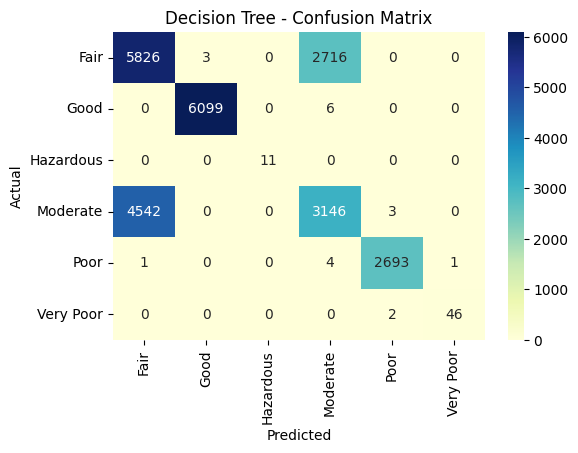

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

*Confusion matrix digunakan untuk melihat jumlah prediksi benar dan salah pada setiap kelas, sehingga dapat diketahui pola kesalahan klasifikasi model.*

**12. Feature Importance Decision Tree**

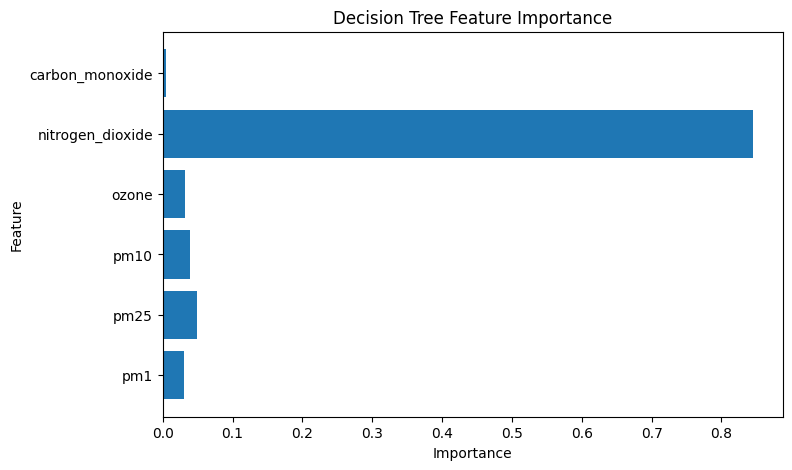

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(X.columns, dt.feature_importances_)
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

*Feature importance menunjukkan kontribusi masing-masing variabel polutan udara terhadap proses pengambilan keputusan model Decision Tree.*

**13. Pembuatan dan Pelatihan Model Random Forest**

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)



*Random Forest merupakan metode ensemble yang menggabungkan banyak pohon keputusan. Penggunaan 200 pohon (n_estimators=200) bertujuan meningkatkan stabilitas dan akurasi model.*

**14. Evaluasi Model Random Forest**

In [ ]:
# Filter out the 'nan' class name as it's no longer present in y_test
filtered_target_names = [name for name in label_encoder.classes_ if pd.notna(name)]

print("=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=filtered_target_names))

print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

        Fair       0.56      0.68      0.62      8545
        Good       1.00      1.00      1.00      6105
   Hazardous       1.00      1.00      1.00        11
    Moderate       0.54      0.41      0.47      7691
        Poor       1.00      1.00      1.00      2699
   Very Poor       1.00      0.96      0.98        48

    accuracy                           0.71     25099
   macro avg       0.85      0.84      0.84     25099
weighted avg       0.71      0.71      0.71     25099

Accuracy Random Forest: 0.7122992947926212


*Evaluasi dilakukan dengan metrik yang sama seperti Decision Tree untuk membandingkan performa kedua metode.*

**15. Confusion Matrix Random Forest**

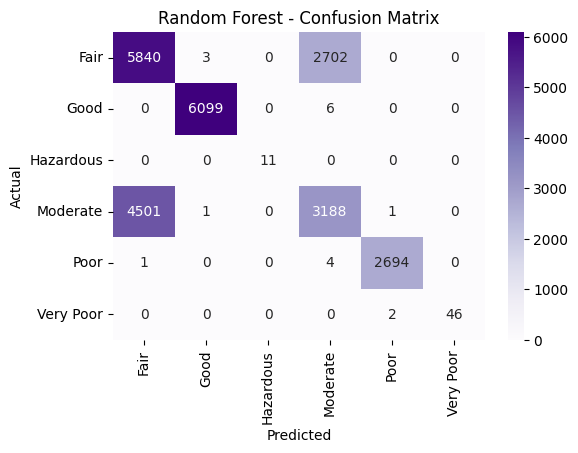

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

*Confusion matrix digunakan untuk melihat jumlah prediksi benar dan salah pada setiap kelas, sehingga dapat diketahui pola kesalahan klasifikasi model.*

**16. Feature Importance Random Forest**

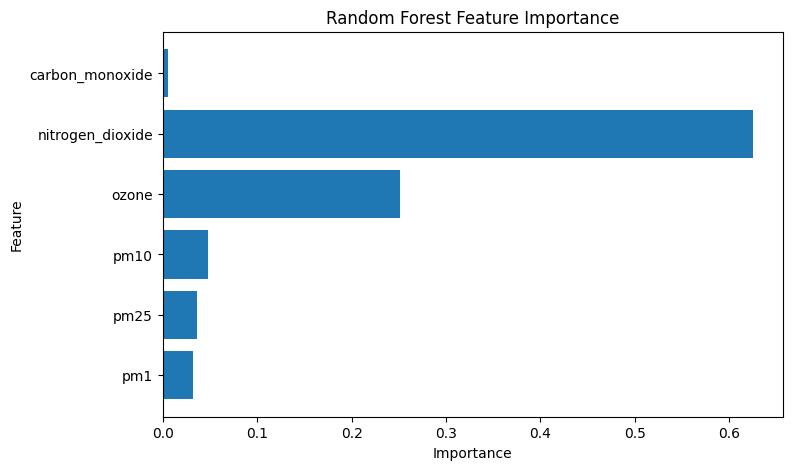

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(X.columns, rf.feature_importances_)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

*Feature importance menunjukkan kontribusi masing-masing variabel polutan udara terhadap proses pengambilan keputusan model Random Forest*